<div style="background:linear-gradient(135deg,#17324D 0%,#2F6690 100%);padding:34px 38px;border-radius:14px;color:white;margin-bottom:20px;box-shadow:0 5px 16px rgba(23,50,77,.18);">
  <div style="font-size:12px;letter-spacing:1.6px;text-transform:uppercase;opacity:.82;font-weight:600;">Workforce Intelligence</div>
  <div style="font-size:34px;line-height:1.16;font-weight:750;margin-top:10px;">The AI Talent Market in 2025 to 2026</div>
  <div style="font-size:17px;line-height:1.5;opacity:.92;margin-top:10px;">Salaries, skills, demand, and work design across 1,500 AI job records</div>
</div>

This notebook turns a compact AI jobs dataset into a decision-oriented market brief. It focuses on the questions a candidate, recruiter, or workforce strategist would ask first: where compensation concentrates, which roles and skills stand out, how experience and education relate to pay, and whether remote or LLM-focused work changes the picture.

**Scope:** Exploratory data analysis only. No predictive modeling is used.


In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import HTML, Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.1f}")

COLORS = {
    "navy": "#17324D",
    "blue": "#2F6690",
    "teal": "#2A9D8F",
    "gold": "#E9C46A",
    "coral": "#E76F51",
    "slate": "#64748B",
    "light": "#EAF0F6",
    "ink": "#1F2937",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 125,
    "savefig.dpi": 160,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#E5E7EB",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})

def usd_thousands(value, _=None):
    return f"${value / 1000:,.0f}k"

def label_bars(ax, fmt=lambda value: f"{value:,.0f}", padding=5, color=None):
    for container in ax.containers:
        labels = [fmt(bar.get_width() if bar.get_width() else bar.get_height()) for bar in container]
        ax.bar_label(container, labels=labels, padding=padding, fontsize=9, color=color or COLORS["ink"])

def show_kpis(items):
    cards = "".join(
        f"<div class='kpi'><div class='kpi-value'>{value}</div><div class='kpi-label'>{label}</div></div>"
        for value, label in items
    )
    display(HTML(f'''
    <style>
      .kpi-grid {{display:grid;grid-template-columns:repeat(4,minmax(150px,1fr));gap:12px;margin:8px 0 18px;}}
      .kpi {{background:linear-gradient(135deg,#17324D,#2F6690);color:white;border-radius:10px;padding:18px 16px;box-shadow:0 3px 10px rgba(23,50,77,.15);}}
      .kpi-value {{font-size:24px;font-weight:700;line-height:1.15;}}
      .kpi-label {{font-size:12px;opacity:.88;margin-top:7px;line-height:1.35;}}
      @media(max-width:800px) {{.kpi-grid {{grid-template-columns:repeat(2,1fr);}}}}
    </style><div class='kpi-grid'>{cards}</div>
    '''))

FILE_NAME = "ai_jobs_market_2025_2026.csv"
candidate_paths = [
    Path("/kaggle/input/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries/ai_jobs_market_2025_2026.csv") / FILE_NAME,
    Path(FILE_NAME),
    Path.cwd() / FILE_NAME,
    Path.home() / "Downloads" / FILE_NAME,
]
if Path("/kaggle/input").exists():
    candidate_paths.extend(Path("/kaggle/input").glob(f"**/{FILE_NAME}"))

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not locate {FILE_NAME}. Update DATA_PATH or attach the dataset to this notebook."
    )

jobs = pd.read_csv(DATA_PATH)
print(f"Loaded {len(jobs):,} rows and {jobs.shape[1]} columns from {DATA_PATH.name}")


Loaded 1,500 rows and 25 columns from ai_jobs_market_2025_2026.csv


## Table of contents

1. [Executive summary](#executive-summary)
2. [Context and methods](#context-and-methods)
3. [Data and quality checks](#data-and-quality-checks)
4. [Salary landscape](#salary-landscape)
5. [Experience and education](#experience-and-education)
6. [Role categories](#role-categories)
7. [Geography](#geography)
8. [Work design and company size](#work-design-and-company-size)
9. [LLM roles and market demand](#llm-roles-and-market-demand)
10. [The skills frontier](#the-skills-frontier)
11. [Takeaways](#takeaways)


## Executive summary

In [ ]:
median_salary = jobs["annual_salary_usd"].median()
remote_friendly_share = jobs["is_remote_friendly"].mean()
llm_share = jobs["is_llm_role"].mean()
median_llm = jobs.loc[jobs["is_llm_role"].eq(1), "annual_salary_usd"].median()
median_non_llm = jobs.loc[jobs["is_llm_role"].eq(0), "annual_salary_usd"].median()

show_kpis([
    (f"${median_salary / 1000:,.0f}k", "Median annual salary"),
    (f"{remote_friendly_share:.1%}", "Hybrid or fully remote"),
    (f"{llm_share:.1%}", "LLM-focused roles"),
    (f"{median_llm / median_non_llm - 1:.1%}", "Raw LLM median salary premium"),
])

display(Markdown(f'''
**What stands out**

* The typical salary is **${median_salary:,.0f}**, with the middle half of records spanning **${jobs.annual_salary_usd.quantile(.25):,.0f} to ${jobs.annual_salary_usd.quantile(.75):,.0f}**.
* Median pay rises from **${jobs.loc[jobs.experience_level.eq('Entry (0-2 yrs)'), 'annual_salary_usd'].median():,.0f}** at entry level to **${jobs.loc[jobs.experience_level.eq('Lead (10+ yrs)'), 'annual_salary_usd'].median():,.0f}** at lead level.
* Big Tech records have a median salary of **${jobs.loc[jobs.company_size.eq('Big Tech (FAANG+)'), 'annual_salary_usd'].median():,.0f}**, compared with **${jobs.loc[jobs.company_size.eq('Startup (1-50)'), 'annual_salary_usd'].median():,.0f}** for startups.
* LLM roles combine a higher median salary, stronger publisher-assigned demand, and faster reported demand growth. These are descriptive associations, not causal effects.
'''))



**What stands out**

* The typical salary is **$180,000**, with the middle half of records spanning **$144,750 to $236,250**.
* Median pay rises from **$145,000** at entry level to **$238,000** at lead level.
* Big Tech records have a median salary of **$234,000**, compared with **$159,500** for startups.
* LLM roles combine a higher median salary, stronger publisher-assigned demand, and faster reported demand growth. These are descriptive associations, not causal effects.


## Context and methods

### About the data

The source is the Kaggle dataset [AI Jobs Market 2025-2026 | Salaries](https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries), published under a CC0 license. The publisher describes the file as a compilation of salary reports and job-market research covering 25 AI roles across 14 countries. The local CSV contains 1,500 records, with full-year 2025 coverage and only January through March for 2026.

### Analytical approach

* Salary comparisons use medians as the primary statistic because compensation is right-skewed.
* Counts are shown beside group estimates so small categories remain visible.
* Skills are split from the pipe-delimited `required_skills` field and counted once per posting.
* Demand score and demand growth are treated as publisher-provided indicators, not independently observed market measures.
* All comparisons are descriptive. They do not adjust for location, role mix, seniority, or other confounders unless explicitly stated.

### Key assumptions

Each row is treated as one job record and `job_id` as its identifier. Salary is interpreted as nominal annual USD compensation. Geographic comparisons are not adjusted for purchasing power, tax, or cost of living.


## Data and quality checks

In [ ]:
profile = pd.DataFrame({
    "Measure": [
        "Rows", "Columns", "Unique roles", "Countries", "Industries",
        "Earliest period", "Latest period", "Median salary", "Memory footprint"
    ],
    "Value": [
        f"{len(jobs):,}", f"{jobs.shape[1]}", f"{jobs.job_title.nunique()}",
        f"{jobs.country.nunique()}", f"{jobs.industry.nunique()}",
        f"{jobs.posting_year.min()}-{jobs.loc[jobs.posting_year.eq(jobs.posting_year.min()), 'posting_month'].min():02d}",
        f"{jobs.posting_year.max()}-{jobs.loc[jobs.posting_year.eq(jobs.posting_year.max()), 'posting_month'].max():02d}",
        f"${jobs.annual_salary_usd.median():,.0f}",
        f"{jobs.memory_usage(deep=True).sum() / 1024**2:.2f} MB",
    ]
})

display(profile.style.hide(axis="index").set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector":"th","props":[("background-color",COLORS["navy"]),("color","white"),("text-align","left")]}]))
display(jobs.head(5))


Measure,Value
Rows,"1,500"
Columns,25
Unique roles,25
Countries,14
Industries,12
Earliest period,2025-01
Latest period,2026-03
Median salary,"$180,000"
Memory footprint,1.26 MB


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,"239,000.0",155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,"166,000.0",90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,"360,000.0",160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,"161,000.0",130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,"283,000.0",140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [ ]:
experience_ranges = {
    "Entry (0-2 yrs)": (0, 2),
    "Mid (3-5 yrs)": (3, 5),
    "Senior (6-9 yrs)": (6, 9),
    "Lead (10+ yrs)": (10, np.inf),
}
experience_consistent = pd.Series(False, index=jobs.index)
for level, (lower, upper) in experience_ranges.items():
    experience_consistent |= jobs["experience_level"].eq(level) & jobs["years_of_experience"].between(lower, upper)

salary_in_range = jobs["annual_salary_usd"].between(jobs["salary_min_usd"], jobs["salary_max_usd"])
expected_tier = pd.cut(
    jobs["annual_salary_usd"],
    bins=[-np.inf, 100_000, 150_000, 200_000, 300_000, np.inf],
    right=False,
    labels=["Entry (<$100k)", "Mid ($100-150k)", "Upper-Mid ($150-200k)", "Senior ($200-300k)", "Elite (>$300k)"],
)

quality = pd.DataFrame([
    ("Missing values", int(jobs.isna().sum().sum()), len(jobs) * jobs.shape[1], "Pass"),
    ("Exact duplicate rows", int(jobs.duplicated().sum()), len(jobs), "Pass"),
    ("Duplicate job IDs", int(jobs.job_id.duplicated().sum()), len(jobs), "Pass"),
    ("Salary outside listed range", int((~salary_in_range).sum()), len(jobs), "Caution"),
    ("Years inconsistent with experience label", int((~experience_consistent).sum()), len(jobs), "Caution"),
    ("Published salary tier inconsistent with salary", int((expected_tier.astype(str) != jobs.salary_tier).sum()), len(jobs), "Caution"),
], columns=["Check", "Affected", "Denominator", "Status"])
quality["Rate"] = quality["Affected"] / quality["Denominator"]

display(quality.style.hide(axis="index")
        .format({"Affected":"{:,}", "Denominator":"{:,}", "Rate":"{:.1%}"})
        .map(lambda value: "color:#B42318;font-weight:600" if value == "Caution" else "color:#067647;font-weight:600", subset=["Status"])
        .set_table_styles([{"selector":"th","props":[("background-color",COLORS["navy"]),("color","white")]}]))

display(Markdown(f'''
**Quality note.** The file is complete and unique at the stated job-record grain. However, **{(~salary_in_range).sum():,} records ({(~salary_in_range).mean():.1%})** have annual salary above the listed maximum, and **{(~experience_consistent).sum():,} records ({(~experience_consistent).mean():.1%})** disagree with the numeric years implied by their experience label. The analysis therefore uses `annual_salary_usd` and the categorical `experience_level` as the primary fields. It does not use the listed salary range or numeric experience as authoritative measures.

Demand score is constant within all **{jobs.job_title.nunique()} job titles**, which indicates that it behaves like a role-level rating rather than an independently measured posting-level signal. The dataset has no row-level source URL, employer name, or collection timestamp. Findings should be read as a polished description of this dataset, not as an audited census of the global AI labor market.
'''))


Check,Affected,Denominator,Status,Rate
Missing values,0,"37,500",Pass,0.0%
Exact duplicate rows,0,"1,500",Pass,0.0%
Duplicate job IDs,0,"1,500",Pass,0.0%
Salary outside listed range,288,"1,500",Caution,19.2%
Years inconsistent with experience label,"1,099","1,500",Caution,73.3%
Published salary tier inconsistent with salary,65,"1,500",Caution,4.3%



**Quality note.** The file is complete and unique at the stated job-record grain. However, **288 records (19.2%)** have annual salary above the listed maximum, and **1,099 records (73.3%)** disagree with the numeric years implied by their experience label. The analysis therefore uses `annual_salary_usd` and the categorical `experience_level` as the primary fields. It does not use the listed salary range or numeric experience as authoritative measures.

Demand score is constant within all **25 job titles**, which indicates that it behaves like a role-level rating rather than an independently measured posting-level signal. The dataset has no row-level source URL, employer name, or collection timestamp. Findings should be read as a polished description of this dataset, not as an audited census of the global AI labor market.


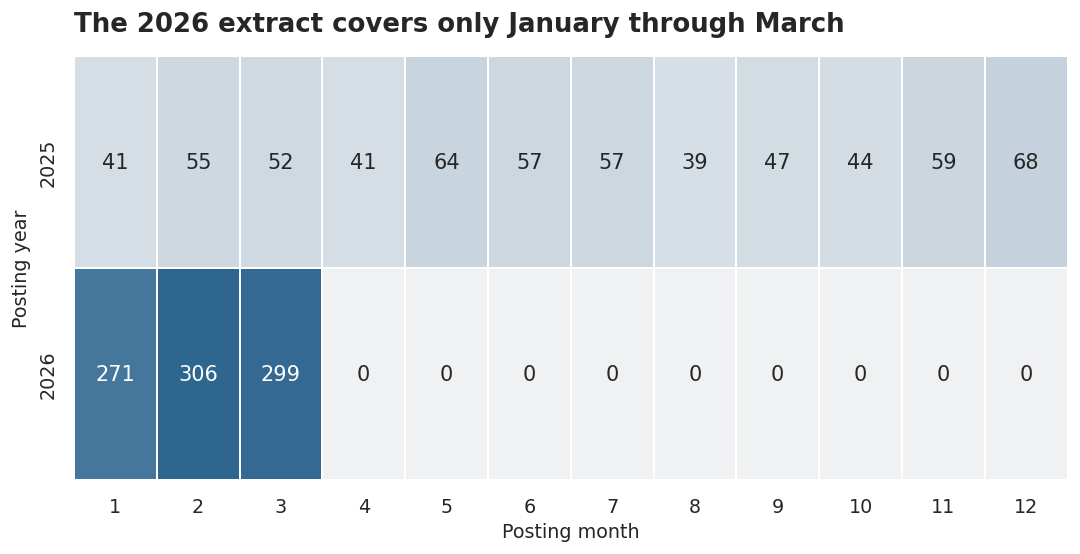

**Observation.** The incomplete 2026 window makes year-over-year posting counts unsuitable for a trend claim. Later sections use the full cross-sectional sample and label time-based comparisons carefully.

In [ ]:
month_coverage = pd.crosstab(jobs["posting_month"], jobs["posting_year"]).reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(8.8, 4.6))
sns.heatmap(month_coverage.T, annot=True, fmt=",.0f", cmap=sns.light_palette(COLORS["blue"], as_cmap=True),
            linewidths=1, linecolor="white", cbar=False, ax=ax)
ax.set_title("The 2026 extract covers only January through March", loc="left", pad=14)
ax.set_xlabel("Posting month")
ax.set_ylabel("Posting year")
plt.tight_layout()
plt.show()

display(Markdown("**Observation.** The incomplete 2026 window makes year-over-year posting counts unsuitable for a trend claim. Later sections use the full cross-sectional sample and label time-based comparisons carefully."))


## Salary landscape

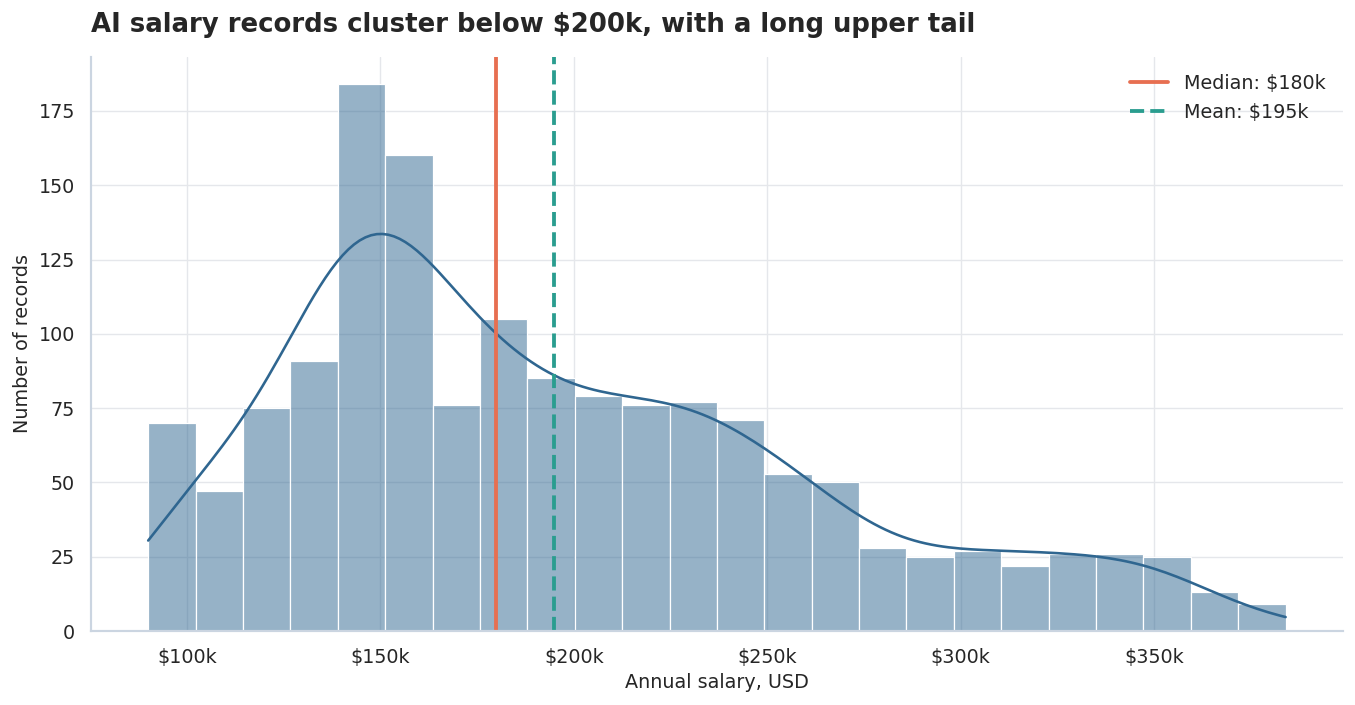

**Observation.** The mean salary of **$194,892** sits above the median of **$180,000**, confirming a right-skewed distribution. The 90th percentile reaches **$297,100**.

In [ ]:
salary = jobs["annual_salary_usd"]
mean_salary = salary.mean()
median_salary = salary.median()

fig, ax = plt.subplots(figsize=(11, 5.8))
sns.histplot(salary, bins=24, kde=True, color=COLORS["blue"], edgecolor="white", linewidth=0.7, ax=ax)
ax.axvline(median_salary, color=COLORS["coral"], linewidth=2.2, label=f"Median: ${median_salary/1000:.0f}k")
ax.axvline(mean_salary, color=COLORS["teal"], linewidth=2.2, linestyle="--", label=f"Mean: ${mean_salary/1000:.0f}k")
ax.set_title("AI salary records cluster below $200k, with a long upper tail", loc="left", pad=14)
ax.set_xlabel("Annual salary, USD")
ax.set_ylabel("Number of records")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

display(Markdown(f"**Observation.** The mean salary of **${mean_salary:,.0f}** sits above the median of **${median_salary:,.0f}**, confirming a right-skewed distribution. The 90th percentile reaches **${salary.quantile(.90):,.0f}**."))


## Experience and education

/tmp/ipykernel_58/2909029585.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


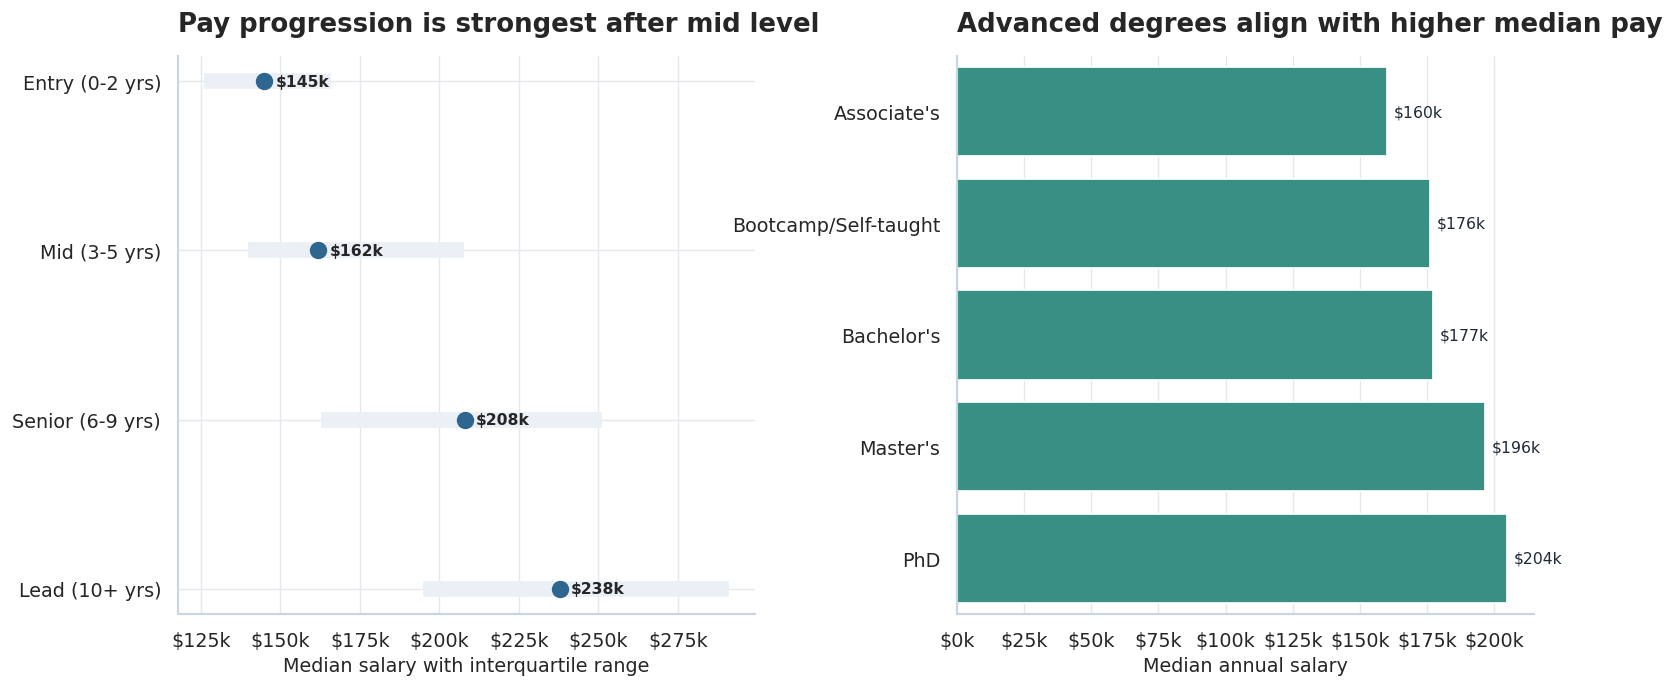

**Observation.** Lead-level median pay is **64.1%** above entry-level pay. PhD-required records show a **15.5%** median premium over bachelor's-required records, but the education comparison is compositional and should not be interpreted as the causal return to a degree.

In [ ]:
experience_order = ["Entry (0-2 yrs)", "Mid (3-5 yrs)", "Senior (6-9 yrs)", "Lead (10+ yrs)"]
education_order = ["Associate's", "Bootcamp/Self-taught", "Bachelor's", "Master's", "PhD"]

experience_summary = jobs.groupby("experience_level")["annual_salary_usd"].agg(
    count="size", median="median", q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75)
).reindex(experience_order)
education_summary = jobs.groupby("education_required")["annual_salary_usd"].agg(count="size", median="median").reindex(education_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"wspace": 0.35})

y = np.arange(len(experience_summary))
axes[0].errorbar(
    experience_summary["median"], y,
    xerr=[experience_summary["median"] - experience_summary["q1"], experience_summary["q3"] - experience_summary["median"]],
    fmt="o", markersize=9, color=COLORS["blue"], ecolor=COLORS["light"], elinewidth=9, capsize=0
)
axes[0].set_yticks(y, experience_summary.index)
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
axes[0].set_xlabel("Median salary with interquartile range")
axes[0].set_title("Pay progression is strongest after mid level", loc="left", pad=14)
for yi, value in zip(y, experience_summary["median"]):
    axes[0].text(value + 3500, yi, f"${value/1000:.0f}k", va="center", fontsize=9, fontweight="bold")

sns.barplot(data=education_summary.reset_index(), y="education_required", x="median", color=COLORS["teal"], ax=axes[1])
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
axes[1].set_xlabel("Median annual salary")
axes[1].set_ylabel("")
axes[1].set_title("Advanced degrees align with higher median pay", loc="left", pad=14)
label_bars(axes[1], lambda value: f"${value/1000:.0f}k", padding=4)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

entry_median = experience_summary.loc["Entry (0-2 yrs)", "median"]
lead_median = experience_summary.loc["Lead (10+ yrs)", "median"]
phd_median = education_summary.loc["PhD", "median"]
bachelor_median = education_summary.loc["Bachelor's", "median"]
display(Markdown(f"**Observation.** Lead-level median pay is **{lead_median / entry_median - 1:.1%}** above entry-level pay. PhD-required records show a **{phd_median / bachelor_median - 1:.1%}** median premium over bachelor's-required records, but the education comparison is compositional and should not be interpreted as the causal return to a degree."))


## Role categories

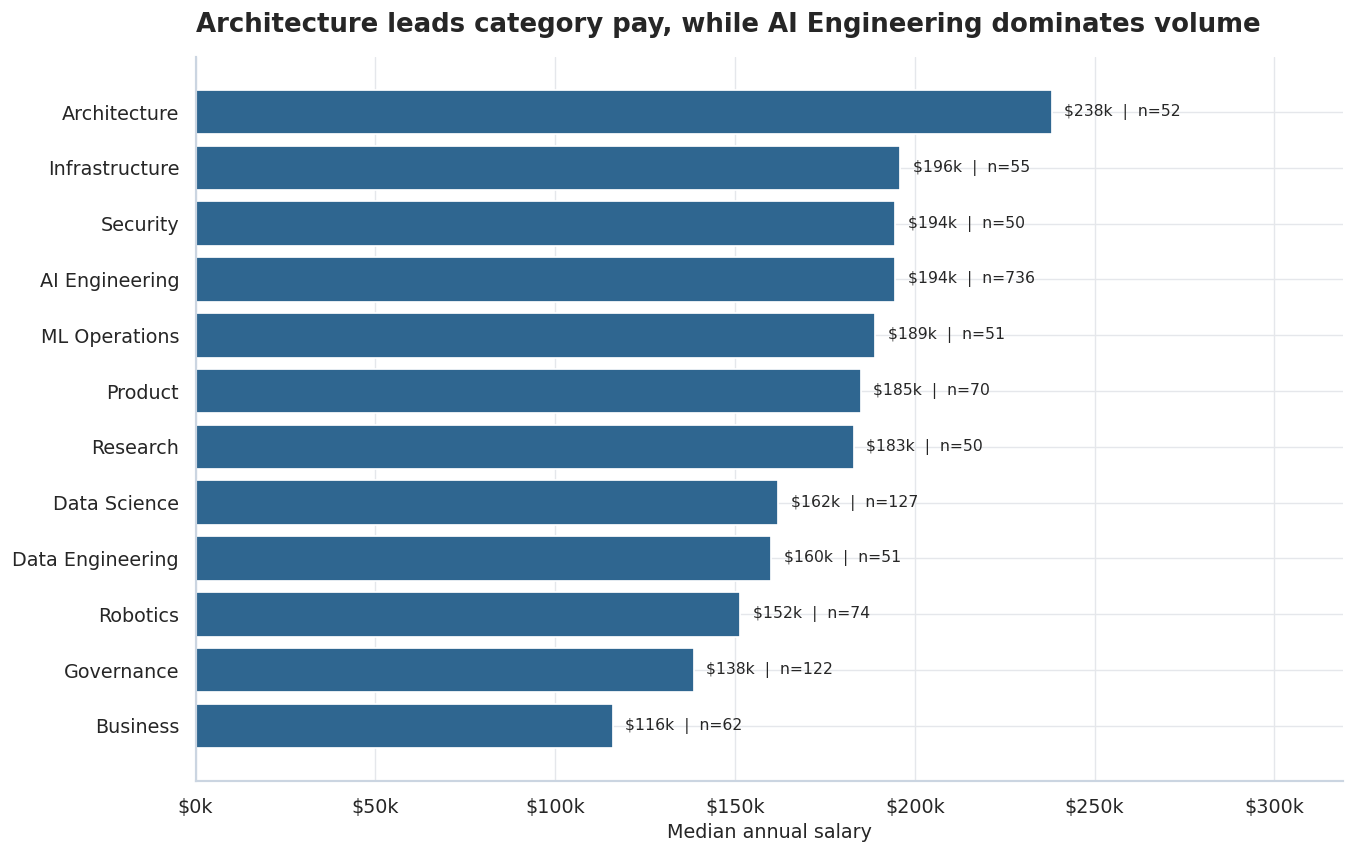

**Observation.** **Architecture** has the highest category median at **$238,000**, based on 52 records. **AI Engineering** accounts for **49.1%** of the dataset, so the overall market picture is heavily shaped by that category.

In [ ]:
category_summary = jobs.groupby("job_category").agg(
    postings=("job_id", "size"),
    median_salary=("annual_salary_usd", "median"),
    median_demand=("demand_score", "median"),
).sort_values("median_salary")

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(category_summary.index, category_summary["median_salary"], color=COLORS["blue"])
ax.xaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
ax.set_xlabel("Median annual salary")
ax.set_title("Architecture leads category pay, while AI Engineering dominates volume", loc="left", pad=14)
for bar, (_, row) in zip(bars, category_summary.iterrows()):
    ax.text(bar.get_width() + 3500, bar.get_y() + bar.get_height()/2,
            f"${row.median_salary/1000:.0f}k  |  n={int(row.postings):,}", va="center", fontsize=9)
ax.set_xlim(0, category_summary.median_salary.max() * 1.34)
sns.despine()
plt.tight_layout()
plt.show()

top_category = category_summary["median_salary"].idxmax()
largest_category = category_summary["postings"].idxmax()
display(Markdown(f"**Observation.** **{top_category}** has the highest category median at **${category_summary.loc[top_category, 'median_salary']:,.0f}**, based on {category_summary.loc[top_category, 'postings']:,} records. **{largest_category}** accounts for **{category_summary.loc[largest_category, 'postings'] / len(jobs):.1%}** of the dataset, so the overall market picture is heavily shaped by that category."))


## Geography

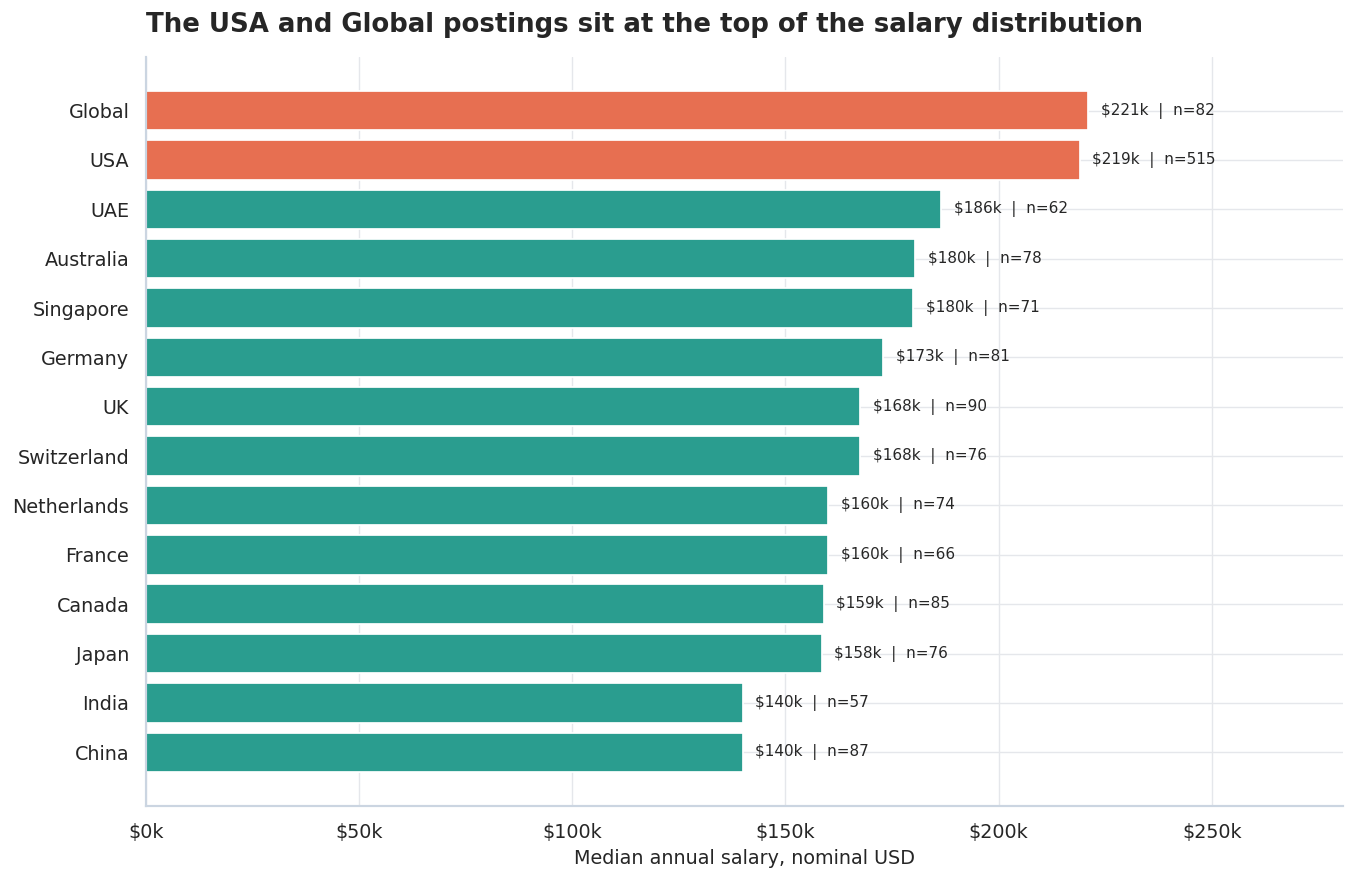

**Observation.** Median salary ranges from **$140,000** in China to **$221,000** for Global postings. This is a nominal USD comparison and does not account for purchasing power, benefits, taxes, or role composition.

In [ ]:
country_summary = jobs.groupby("country").agg(
    postings=("job_id", "size"),
    median_salary=("annual_salary_usd", "median"),
).sort_values("median_salary")

fig, ax = plt.subplots(figsize=(11, 7.2))
country_colors = [COLORS["coral"] if country in {"USA", "Global"} else COLORS["teal"] for country in country_summary.index]
bars = ax.barh(country_summary.index, country_summary["median_salary"], color=country_colors)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
ax.set_xlabel("Median annual salary, nominal USD")
ax.set_title("The USA and Global postings sit at the top of the salary distribution", loc="left", pad=14)
for bar, (_, row) in zip(bars, country_summary.iterrows()):
    ax.text(bar.get_width() + 3000, bar.get_y() + bar.get_height()/2,
            f"${row.median_salary/1000:.0f}k  |  n={int(row.postings)}", va="center", fontsize=8.8)
ax.set_xlim(0, country_summary.median_salary.max() * 1.27)
sns.despine()
plt.tight_layout()
plt.show()

highest_country = country_summary["median_salary"].idxmax()
lowest_country = country_summary["median_salary"].idxmin()
display(Markdown(f"**Observation.** Median salary ranges from **${country_summary.loc[lowest_country, 'median_salary']:,.0f}** in {lowest_country} to **${country_summary.loc[highest_country, 'median_salary']:,.0f}** for {highest_country} postings. This is a nominal USD comparison and does not account for purchasing power, benefits, taxes, or role composition."))


## Work design and company size

/tmp/ipykernel_58/1839525459.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


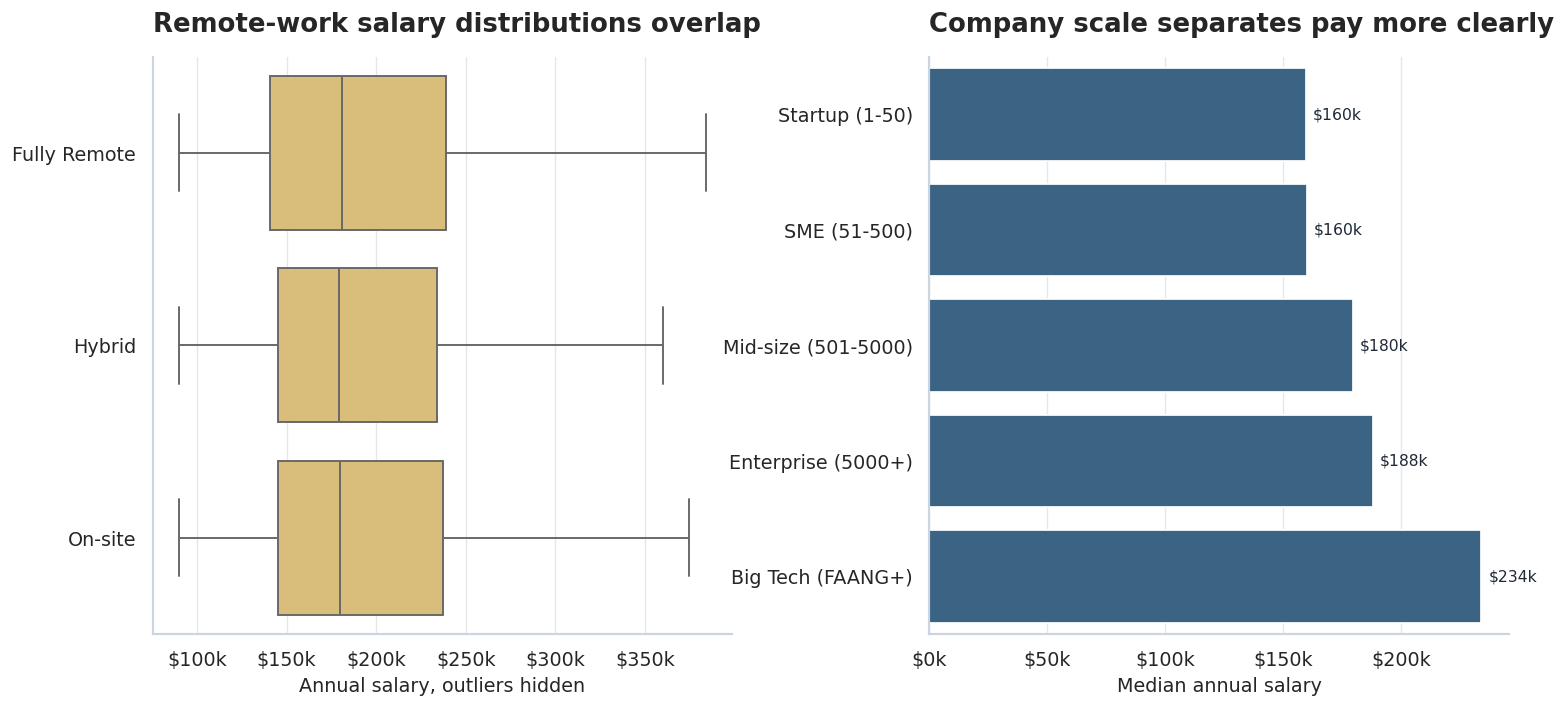

**Observation.** Fully remote and on-site medians differ by only **0.6%**. Company size has a much larger descriptive gap: Big Tech median pay is **46.7%** above the startup median.

In [ ]:
company_order = ["Startup (1-50)", "SME (51-500)", "Mid-size (501-5000)", "Enterprise (5000+)", "Big Tech (FAANG+)"]
company_summary = jobs.groupby("company_size")["annual_salary_usd"].agg(count="size", median="median").reindex(company_order)
remote_summary = jobs.groupby("remote_work")["annual_salary_usd"].agg(count="size", median="median", mean="mean").sort_values("median", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"wspace": 0.34})

sns.boxplot(data=jobs, x="annual_salary_usd", y="remote_work", order=["Fully Remote", "Hybrid", "On-site"],
            color=COLORS["gold"], showfliers=False, linewidth=1.1, ax=axes[0])
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
axes[0].set_xlabel("Annual salary, outliers hidden")
axes[0].set_ylabel("")
axes[0].set_title("Remote-work salary distributions overlap", loc="left", pad=14)

sns.barplot(data=company_summary.reset_index(), y="company_size", x="median", color=COLORS["blue"], ax=axes[1])
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
axes[1].set_xlabel("Median annual salary")
axes[1].set_ylabel("")
axes[1].set_title("Company scale separates pay more clearly", loc="left", pad=14)
label_bars(axes[1], lambda value: f"${value/1000:.0f}k", padding=4)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

full_remote = remote_summary.loc["Fully Remote", "median"]
onsite = remote_summary.loc["On-site", "median"]
big_tech = company_summary.loc["Big Tech (FAANG+)", "median"]
startup = company_summary.loc["Startup (1-50)", "median"]
display(Markdown(f"**Observation.** Fully remote and on-site medians differ by only **{full_remote / onsite - 1:.1%}**. Company size has a much larger descriptive gap: Big Tech median pay is **{big_tech / startup - 1:.1%}** above the startup median."))


## LLM roles and market demand

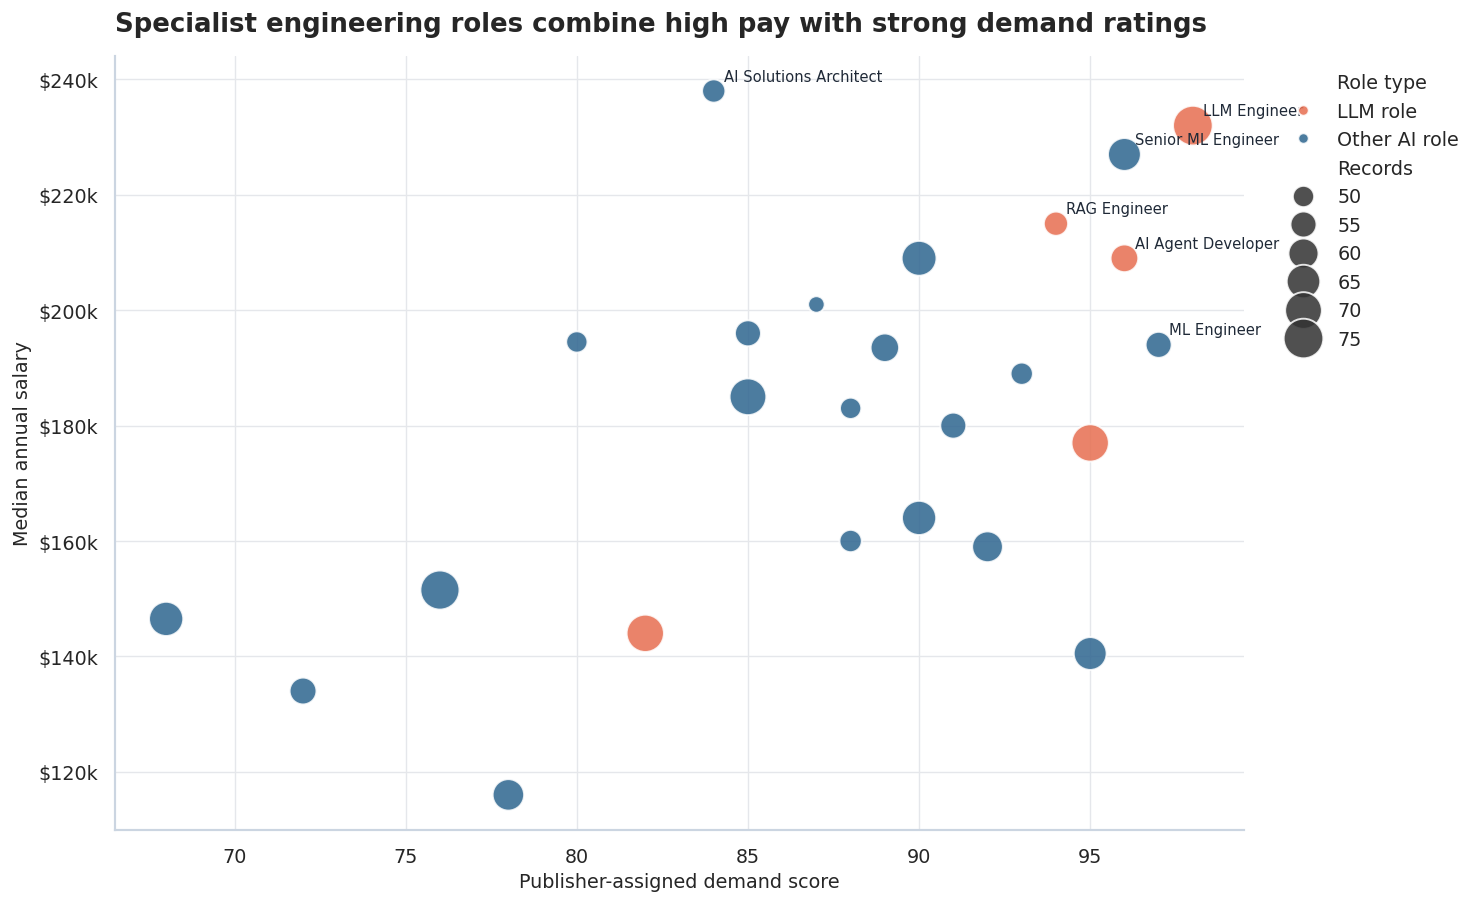

### High-pay, high-demand shortlist

job_title,postings,median_salary,demand_score,demand_growth,Role type
LLM Engineer,75,"$232,000",98,51.8%,LLM role
Senior ML Engineer,64,"$227,000",96,49.0%,Other AI role
RAG Engineer,53,"$215,000",94,55.3%,LLM role
AI Agent Developer,57,"$209,000",96,49.9%,LLM role
Multimodal AI Engineer,67,"$209,000",90,16.2%,Other AI role


In [ ]:
role_summary = jobs.groupby("job_title").agg(
    postings=("job_id", "size"),
    median_salary=("annual_salary_usd", "median"),
    demand_score=("demand_score", "median"),
    demand_growth=("demand_growth_yoy_pct", "mean"),
    llm_share=("is_llm_role", "mean"),
).reset_index()
role_summary["Role type"] = np.where(role_summary["llm_share"].ge(.5), "LLM role", "Other AI role")
role_summary["Records"] = role_summary["postings"]

fig, ax = plt.subplots(figsize=(12, 7.4))
sns.scatterplot(
    data=role_summary, x="demand_score", y="median_salary", size="Records", hue="Role type",
    sizes=(90, 520), palette={"LLM role": COLORS["coral"], "Other AI role": COLORS["blue"]},
    alpha=.86, edgecolor="white", linewidth=1.1, ax=ax
)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
ax.set_xlabel("Publisher-assigned demand score")
ax.set_ylabel("Median annual salary")
ax.set_title("Specialist engineering roles combine high pay with strong demand ratings", loc="left", pad=14)

labels = role_summary.nlargest(5, "median_salary")["job_title"].tolist()
labels += role_summary.nlargest(3, "demand_score")["job_title"].tolist()
for _, row in role_summary[role_summary.job_title.isin(set(labels))].iterrows():
    ax.annotate(row.job_title, (row.demand_score, row.median_salary), xytext=(6, 6),
                textcoords="offset points", fontsize=8.5, color=COLORS["ink"])
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="")
sns.despine()
plt.tight_layout()
plt.show()

shortlist = role_summary.query("median_salary >= 200000 and demand_score >= 90")\
    .sort_values(["median_salary", "demand_score"], ascending=False)\
    .loc[:, ["job_title", "postings", "median_salary", "demand_score", "demand_growth", "Role type"]]
display(Markdown("### High-pay, high-demand shortlist"))
display(shortlist.style.hide(axis="index")
        .format({"median_salary":"${:,.0f}", "demand_score":"{:.0f}", "demand_growth":"{:.1f}%"})
        .set_table_styles([{"selector":"th","props":[("background-color",COLORS["navy"]),("color","white")]}]))


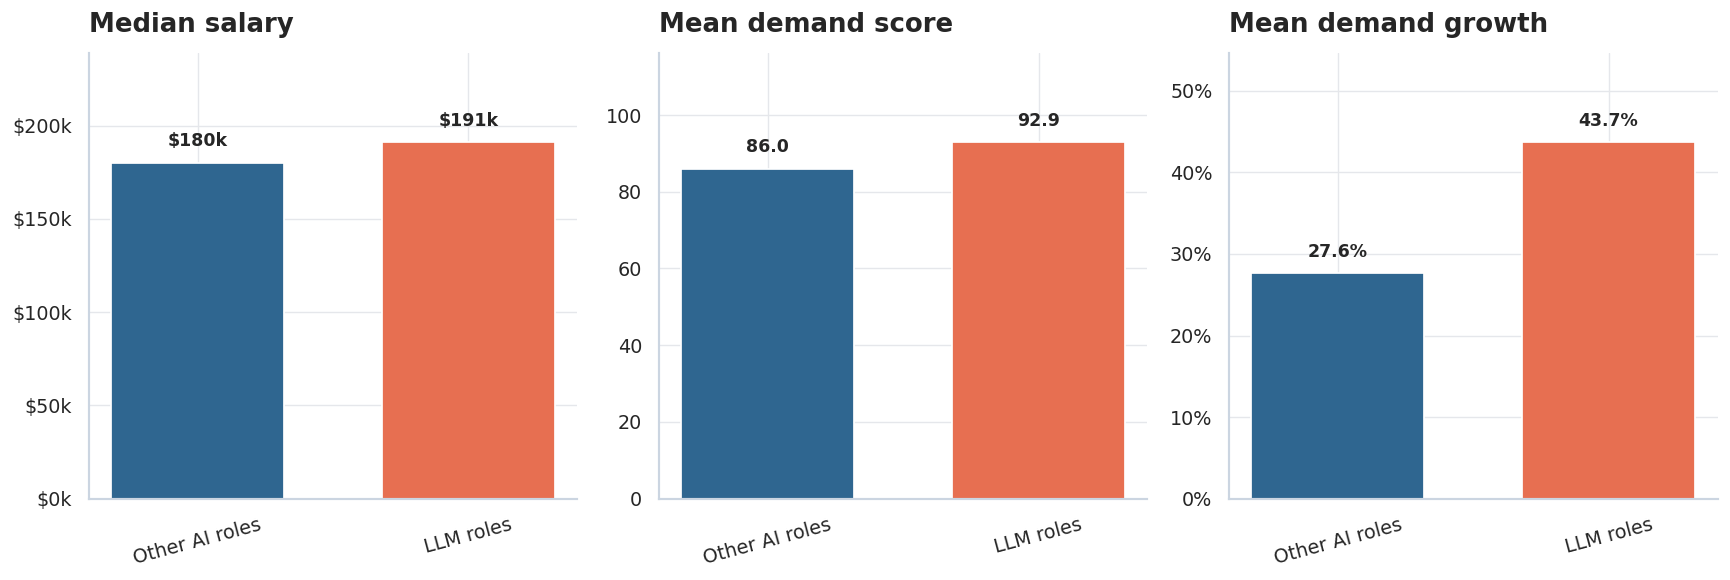

**Observation.** LLM roles represent **21.8%** of records. Their median salary is **6.1%** higher, while their mean demand-growth indicator is **16.1 percentage points** higher. These raw gaps partly reflect the mix of job titles and should not be read as an isolated LLM effect.

In [ ]:
llm_comparison = jobs.groupby("is_llm_role").agg(
    records=("job_id", "size"),
    median_salary=("annual_salary_usd", "median"),
    mean_demand=("demand_score", "mean"),
    mean_growth=("demand_growth_yoy_pct", "mean"),
).rename(index={0: "Other AI roles", 1: "LLM roles"})

metrics = [
    ("median_salary", "Median salary", lambda value: f"${value/1000:.0f}k"),
    ("mean_demand", "Mean demand score", lambda value: f"{value:.1f}"),
    ("mean_growth", "Mean demand growth", lambda value: f"{value:.1f}%"),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
for ax, (column, title, formatter) in zip(axes, metrics):
    values = llm_comparison[column]
    bars = ax.bar(values.index, values.values, color=[COLORS["blue"], COLORS["coral"]], width=.64)
    ax.set_title(title, loc="left", pad=12)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.set_ylim(0, values.max() * 1.25)
    if column == "median_salary":
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
    elif column == "mean_growth":
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, value + values.max()*.035, formatter(value),
                ha="center", va="bottom", fontweight="bold", fontsize=10)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

display(Markdown(f"**Observation.** LLM roles represent **{llm_share:.1%}** of records. Their median salary is **{median_llm / median_non_llm - 1:.1%}** higher, while their mean demand-growth indicator is **{llm_comparison.loc['LLM roles', 'mean_growth'] - llm_comparison.loc['Other AI roles', 'mean_growth']:.1f} percentage points** higher. These raw gaps partly reflect the mix of job titles and should not be read as an isolated LLM effect."))


## The skills frontier

/tmp/ipykernel_58/155919907.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


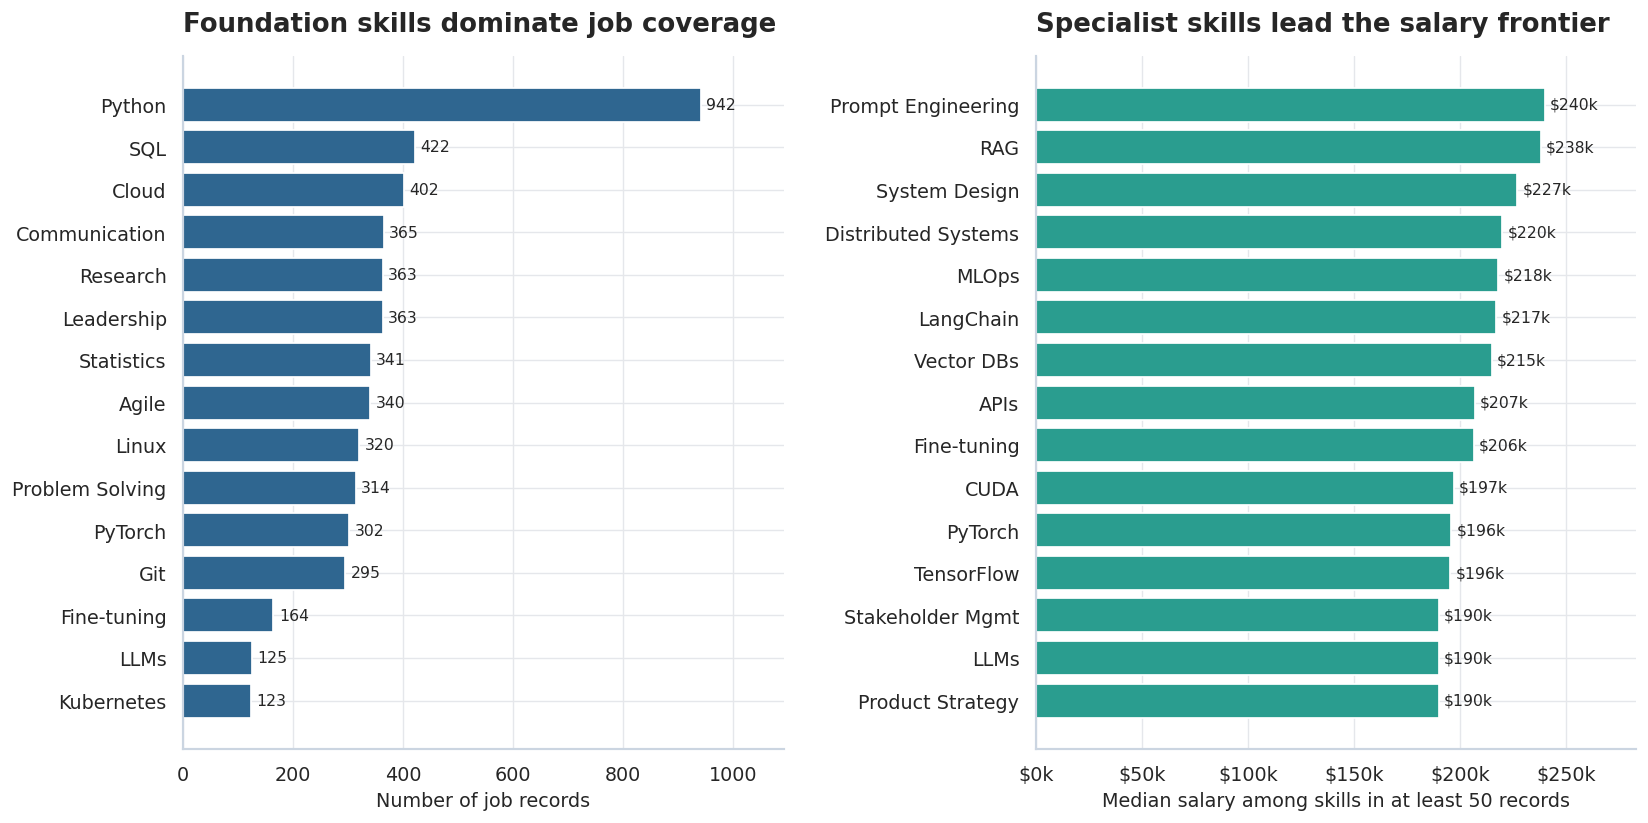

**Observation.** **Python** appears in **942 records (62.8%)**. Among skills appearing in at least 50 records, **Prompt Engineering** has the highest median salary at **$240,000**. Skill figures are associations because each record lists several skills and role mix drives much of the difference.

In [ ]:
skills = jobs.assign(skill=jobs["required_skills"].str.split("|")).explode("skill")
skills["skill"] = skills["skill"].str.strip()

skill_summary = skills.groupby("skill").agg(
    postings=("job_id", "nunique"),
    median_salary=("annual_salary_usd", "median"),
    mean_demand=("demand_score", "mean"),
    llm_share=("is_llm_role", "mean"),
).sort_values("postings", ascending=False)

common_skills = skill_summary.head(15).sort_values("postings")
salary_skills = skill_summary.query("postings >= 50").nlargest(15, "median_salary").sort_values("median_salary")

fig, axes = plt.subplots(1, 2, figsize=(15, 7.2), gridspec_kw={"wspace": 0.42})

axes[0].barh(common_skills.index, common_skills["postings"], color=COLORS["blue"])
axes[0].set_title("Foundation skills dominate job coverage", loc="left", pad=14)
axes[0].set_xlabel("Number of job records")
for y, value in enumerate(common_skills["postings"]):
    axes[0].text(value + 10, y, f"{value:,}", va="center", fontsize=9)
axes[0].set_xlim(0, common_skills.postings.max() * 1.16)

axes[1].barh(salary_skills.index, salary_skills["median_salary"], color=COLORS["teal"])
axes[1].set_title("Specialist skills lead the salary frontier", loc="left", pad=14)
axes[1].set_xlabel("Median salary among skills in at least 50 records")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(usd_thousands))
for y, value in enumerate(salary_skills["median_salary"]):
    axes[1].text(value + 2500, y, f"${value/1000:.0f}k", va="center", fontsize=9)
axes[1].set_xlim(0, salary_skills.median_salary.max() * 1.18)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

most_common_skill = skill_summary.index[0]
highest_salary_skill = salary_skills.index[-1]
display(Markdown(f"**Observation.** **{most_common_skill}** appears in **{skill_summary.loc[most_common_skill, 'postings']:,} records ({skill_summary.loc[most_common_skill, 'postings'] / len(jobs):.1%})**. Among skills appearing in at least 50 records, **{highest_salary_skill}** has the highest median salary at **${skill_summary.loc[highest_salary_skill, 'median_salary']:,.0f}**. Skill figures are associations because each record lists several skills and role mix drives much of the difference."))


## Takeaways

In [ ]:
entry_median = jobs.loc[jobs.experience_level.eq("Entry (0-2 yrs)"), "annual_salary_usd"].median()
lead_median = jobs.loc[jobs.experience_level.eq("Lead (10+ yrs)"), "annual_salary_usd"].median()
big_tech_median = jobs.loc[jobs.company_size.eq("Big Tech (FAANG+)"), "annual_salary_usd"].median()
startup_median = jobs.loc[jobs.company_size.eq("Startup (1-50)"), "annual_salary_usd"].median()

display(Markdown(f'''
### A concise market read

1. **Seniority is the clearest pay separator.** Lead-level median salary is **{lead_median / entry_median - 1:.1%}** above entry level.
2. **Employer scale matters more than work location in this sample.** Big Tech median pay is **{big_tech_median / startup_median - 1:.1%}** above startups, while fully remote and on-site medians are almost equal.
3. **LLM roles occupy a valuable niche.** They make up **{llm_share:.1%}** of records and show a **{median_llm / median_non_llm - 1:.1%}** raw median salary premium.
4. **Breadth and specialization play different career roles.** Python, SQL, and cloud skills maximize coverage; Prompt Engineering, RAG, System Design, and Distributed Systems sit near the salary frontier.
5. **Use the dataset as a directional benchmark.** Inconsistent range and experience fields, fixed title-level demand scores, partial 2026 coverage, and missing row-level provenance limit external generalization.

### Practical implications

* **For candidates:** Build broad foundations first, then add a specialist layer aligned with high-value roles.
* **For recruiters:** Benchmark compensation by seniority, company scale, geography, and role together rather than using a single market average.
* **For analysts:** Reconcile the experience and salary-range fields before modeling, and obtain auditable posting-level sources before making market-wide forecasts.
'''))



### A concise market read

1. **Seniority is the clearest pay separator.** Lead-level median salary is **64.1%** above entry level.
2. **Employer scale matters more than work location in this sample.** Big Tech median pay is **46.7%** above startups, while fully remote and on-site medians are almost equal.
3. **LLM roles occupy a valuable niche.** They make up **21.8%** of records and show a **6.1%** raw median salary premium.
4. **Breadth and specialization play different career roles.** Python, SQL, and cloud skills maximize coverage; Prompt Engineering, RAG, System Design, and Distributed Systems sit near the salary frontier.
5. **Use the dataset as a directional benchmark.** Inconsistent range and experience fields, fixed title-level demand scores, partial 2026 coverage, and missing row-level provenance limit external generalization.

### Practical implications

* **For candidates:** Build broad foundations first, then add a specialist layer aligned with high-value roles.
* **For recruiters:** Benchmark compensation by seniority, company scale, geography, and role together rather than using a single market average.
* **For analysts:** Reconcile the experience and salary-range fields before modeling, and obtain auditable posting-level sources before making market-wide forecasts.


---

### Reproducibility notes

This notebook uses only pandas, NumPy, Matplotlib, Seaborn, and IPython display utilities. It resolves the CSV automatically on Kaggle, in the current working directory, or in the local Downloads folder. All summaries and observations are computed from the loaded file during execution.

**Dataset:** [AI Jobs Market 2025-2026 | Salaries](https://www.kaggle.com/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries)  
**License:** CC0: Public Domain  
**Analysis type:** Descriptive exploratory data analysis


## Notebook Summary

This notebook performs an **exploratory data analysis (EDA)** on a compact AI jobs dataset to provide insights into the AI talent market for 2025-2026. It addresses key questions related to compensation, roles, skills, experience, education, work design (remote vs. on-site), and the impact of LLM-focused roles.

### Technologies Used

The notebook primarily leverages the following Python libraries:

*   **`pandas`**: For data manipulation, cleaning, and aggregation.
*   **`numpy`**: For numerical operations, especially with array-like objects.
*   **`matplotlib.pyplot`**: For creating static, interactive, and animated visualizations.
*   **`seaborn`**: For making aesthetically pleasing statistical graphics, building on Matplotlib.
*   **`pathlib`**: For object-oriented filesystem paths (to locate the data file).
*   **`IPython.display`**: For enhancing the display of various data types in the notebook (e.g., `HTML`, `Markdown`).

### How it Works

1.  **Setup and Utilities**: It begins by importing necessary libraries and defining custom functions for styling plots, formatting currency, labeling bars in charts, and displaying Key Performance Indicators (KPIs). A custom color palette is also defined for consistent visualization.
2.  **Data Loading**: The notebook automatically locates and loads the `ai_jobs_market_2025_2026.csv` dataset into a pandas DataFrame, providing flexibility for different environments (Kaggle, local machine).
3.  **Executive Summary**: Presents a high-level overview of key market metrics, such as median salaries, prevalence of remote work, LLM roles, and salary premiums for experience and company size.
4.  **Context and Methods**: Details the data source, the analytical approach (e.g., using medians due to skewed salary data), and key assumptions made during the analysis.
5.  **Data Quality Checks**: Performs an assessment of data quality, including checks for missing values, duplicate records, consistency of experience levels with years, and salary ranges. It also highlights limitations of the dataset, such as incomplete 2026 coverage and fixed demand scores.
6.  **Exploratory Analysis**: The core of the notebook involves various sections dedicated to exploring different aspects of the AI job market:
    *   **Salary Landscape**: Visualizes the overall distribution of annual salaries using histograms.
    *   **Experience and Education**: Compares median salaries across different experience levels and educational backgrounds using error bar and bar charts.
    *   **Role Categories**: Analyzes salary and posting volumes for different job categories.
    *   **Geography**: Examines median salaries by country.
    *   **Work Design and Company Size**: Compares salary distributions based on remote work options and company size.
    *   **LLM Roles and Market Demand**: Investigates the characteristics of LLM-focused roles in terms of salary, demand, and growth, using scatter plots and bar charts.
    *   **The Skills Frontier**: Identifies both common and high-paying specialist skills by parsing `required_skills` and visualizing their frequency and associated median salaries.
7.  **Takeaways**: Concludes with a concise summary of the main findings and practical implications for candidates, recruiters, and analysts, reinforcing the insights gained from the EDA.

All summaries, observations, and visualizations are generated directly from the loaded data, ensuring reproducibility of the analysis.

## Extracted Technical Terms and Methodologies

Based on the analysis performed in this notebook, here are the key technical terms and methodologies used:

### Data Processing & Manipulation
*   **`pandas` DataFrame**: Core data structure for tabular data.
*   **`numpy`**: Numerical operations, especially `np.inf` for defining ranges.
*   **`pd.set_option("display.max_columns", 30)`**: Pandas display configuration for column limits.
*   **`pd.set_option("display.float_format", lambda value: f"{value:,.1f}")`**: Pandas display configuration for float formatting.
*   **`Pathlib`**: Object-oriented filesystem paths for flexible data loading.
*   **`pd.read_csv()`**: Loading data from a CSV file.
*   **`df.shape`**: Checking the dimensions of a DataFrame.
*   **`df.columns`**: Accessing column names.
*   **`df.head()`**: Displaying the first few rows of a DataFrame.
*   **`df.info()`**: Getting a summary of a DataFrame including data types and non-null values (though not explicitly used, `df.isna().sum().sum()` implies similar data quality checks).
*   **`df.median()`**: Calculating the median of a series.
*   **`df.mean()`**: Calculating the mean of a series.
*   **`df.quantile()`**: Calculating quantiles (e.g., 25th, 75th, 90th percentiles).
*   **`df.groupby()`**: Grouping data by one or more columns.
*   **`df.agg()`**: Performing aggregation operations (e.g., `size`, `median`, `mean`, `nunique`).
*   **`df.reindex()`**: Reordering or conforming to a new index.
*   **`df.loc[]`**: Label-based indexing for selection.
*   **`df.eq()`**: Checking for equality.
*   **`df.between()`**: Checking if values are within a range.
*   **`pd.cut()`**: Binning values into discrete intervals.
*   **`df.assign()`**: Assigning new columns to a DataFrame.
*   **`str.split("|")`**: Splitting strings by a delimiter.
*   **`explode("skill")`**: Transforming list-like entries into separate rows.
*   **`str.strip()`**: Removing leading/trailing whitespace from strings.
*   **`df.nlargest()`**: Selecting the largest `n` values.
*   **`df.query()`**: Querying DataFrame rows using a boolean expression.
*   **`pd.crosstab()`**: Computing a frequency table of two (or more) factors.
*   **`warnings.filterwarnings("ignore")`**: Suppressing warnings.

### Statistical Concepts & Metrics
*   **Exploratory Data Analysis (EDA)**: The overarching methodology of the notebook.
*   **Median**: Primary statistic for salary comparisons due to right-skewed data.
*   **Mean**: Average value.
*   **Interquartile Range (IQR)**: Difference between the 75th and 25th percentiles, indicating spread.
*   **Quantiles/Percentiles**: Divisions of probability distribution.
*   **Right-skewed distribution**: Data distribution where the tail is longer on the right side.
*   **`count` (`size`)**: Number of records/occurrences.
*   **`nunique`**: Number of unique values.
*   **Demand Score**: Publisher-assigned indicator for job demand.
*   **Demand Growth (YoY %)**: Year-over-year percentage growth in demand.
*   **Compositional analysis**: Understanding how groups are formed rather than causal effects.

### Visualization & Presentation
*   **`matplotlib.pyplot` (`plt`)**: Core library for plotting.
*   **`seaborn` (`sns`)**: High-level library for statistical graphics.
*   **Custom color palette (`COLORS`)**: For consistent visual styling.
*   **`sns.set_theme(style="whitegrid", context="notebook")`**: Setting global plot styles.
*   **`plt.rcParams.update()`**: Customizing Matplotlib parameters.
*   **`histplot`**: Histogram plot for visualizing distributions.
*   **`ax.axvline()`**: Adding vertical lines to plots (e.g., for mean/median).
*   **`errorbar`**: Plotting points with error bars (e.g., for median and IQR).
*   **`barplot`**: Bar charts for comparing categorical data.
*   **`boxplot`**: Box plot for visualizing salary distributions and showing quartiles/outliers.
*   **`scatterplot`**: Scatter plot for showing relationships between two variables with point size and color variations.
*   **`heatmap`**: Visualizing data in a matrix form with colors (e.g., month coverage).
*   **`plt.tight_layout()`**: Adjusting plot parameters for a tight layout.
*   **`sns.despine()`**: Removing top and right spines from plots.
*   **`mtick.FuncFormatter`**: Customizing axis tick labels (e.g., `usd_thousands`).
*   **`label_bars()`**: Custom function to add labels to bars in plots.
*   **`show_kpis()`**: Custom function to display Key Performance Indicators (KPIs) in an HTML card format.
*   **`IPython.display.HTML`**: Displaying HTML content in the notebook.
*   **`IPython.display.Markdown`**: Displaying Markdown content in the notebook.
*   **`ax.annotate()`**: Adding text annotations to plots.
*   **`plt.legend()`**: Adding a legend to a plot.
*   **`plt.show()`**: Displaying the generated plot.
*   **`df.style.hide(axis="index").format().set_table_styles()`**: Styling pandas DataFrames for better presentation.

### AI/ML Specific Terms
*   **LLM-focused roles**: Roles specifically centered around Large Language Models.
*   **CNN architectures (AMFR-Net)**: Convolutional Neural Network (from example 1).
*   **Multi-label remote sensing image classification**: A specific computer vision task (from example 1).
*   **Dynamic Path Selection module**: A neural network component (from example 1).
*   **Asymmetric residual dense blocks**: Architectural components in CNNs (from example 1).
*   **Dilated convolution paths**: A type of convolution (from example 1).
*   **Hierarchical SE–Spatial Attention blocks**: Attention mechanism in CNNs (from example 1).
*   **Grad-CAM, LIME, SHAP**: Explainable AI (XAI) techniques (from example 4).
*   **Transformer-based architectures**: Deep learning models (from example 4).
*   **Generative AI**: General term for AI models that generate content.
*   **Prompt Engineering**: Crafting inputs for generative models.
*   **RAG (Retrieval-Augmented Generation)**: An architectural pattern for LLMs.
*   **Vector DBs**: Vector databases, often used with LLMs.
*   **Fine-tuning**: Adapting pre-trained models to specific tasks.
*   **CUDA**: Parallel computing platform for GPUs (common in deep learning).
*   **PyTorch, TensorFlow**: Popular deep learning frameworks.
*   **MLOps**: Machine Learning Operations.
*   **K-Means, DBSCAN, Agglomerative Clustering**: Unsupervised learning/clustering algorithms (from example 3).
*   **Principal Component Analysis (PCA)**: Dimensionality reduction technique (from example 3).
*   **Silhouette scores**: Metric for evaluating clustering performance (from example 3).